# FlowGuard-MPC: Adaptive Model-Predictive Production Choke Controller for Autonomous Safe Oil Well Optimization
### Honeywell Hackathon Round 2 Deliverable
**Author**: Shyambaskar Sriram (SASTRA University)

This notebook contains the end-to-end implementation of **FlowGuard-MPC**, an Autonomous Model Predictive Controller (MPC) with an explicit Hard-Guard Safety Filter and Candidate Rejection Engine for a single naturally flowing oil well.

## 1. Import Libraries and Resolve Dataset Path
Uses dynamic relative path resolution so the notebook executes seamlessly on any machine or evaluator directory.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from system_id import find_dataset_path, DynamicSystemModel

# Resolve dataset path dynamically
dataset_path = find_dataset_path()
print('Resolved Dataset Path:', dataset_path)

if os.path.exists(dataset_path):
    df = pd.read_csv(dataset_path)
    print('Dataset Shape:', df.shape)
    display(df.head(10))
else:
    print('Using dynamic online simulation mode.')

Resolved Dataset Path: C:\Honeywell\Dataset\c5c8d485-e827-4cd6-a3f3-631921a2bfd3Autonomous_Choke_Control_Simulated_Dataset.csv
Dataset Shape: (120, 6)


,Time_hr,Choke_pct,OilRate_bbl_hr,WHP_psi,FLP_psi,BHP_psi
0,0,30,90.00,250.00,180.00,3000.00
1,1,30,91.12,252.54,181.72,3017.37
2,2,30,91.45,254.71,183.67,3031.08
3,3,30,91.53,257.17,184.33,3040.00
4,4,30,92.17,257.61,184.26,3047.91
5,5,30,91.69,259.56,184.61,3052.64
6,6,30,93.28,260.89,185.40,3056.96
7,7,30,92.97,262.30,185.47,3066.33
8,8,30,92.68,263.26,185.80,3079.38
9,9,30,92.90,263.57,186.80,3082.16


## 2. Dynamic System Identification & Step-Test Analysis
Analyzing the open-loop step test responses to determine process gains for Q, WHP, FLP, and BHP.

Safety Envelope Limits: {'WHP_min': 210.0, 'FLP_min': 150.0, 'BHP_min': 2850.0, 'max_ramp_rate': 5.0, 'max_choke': 100.0, 'min_choke': 0.0}


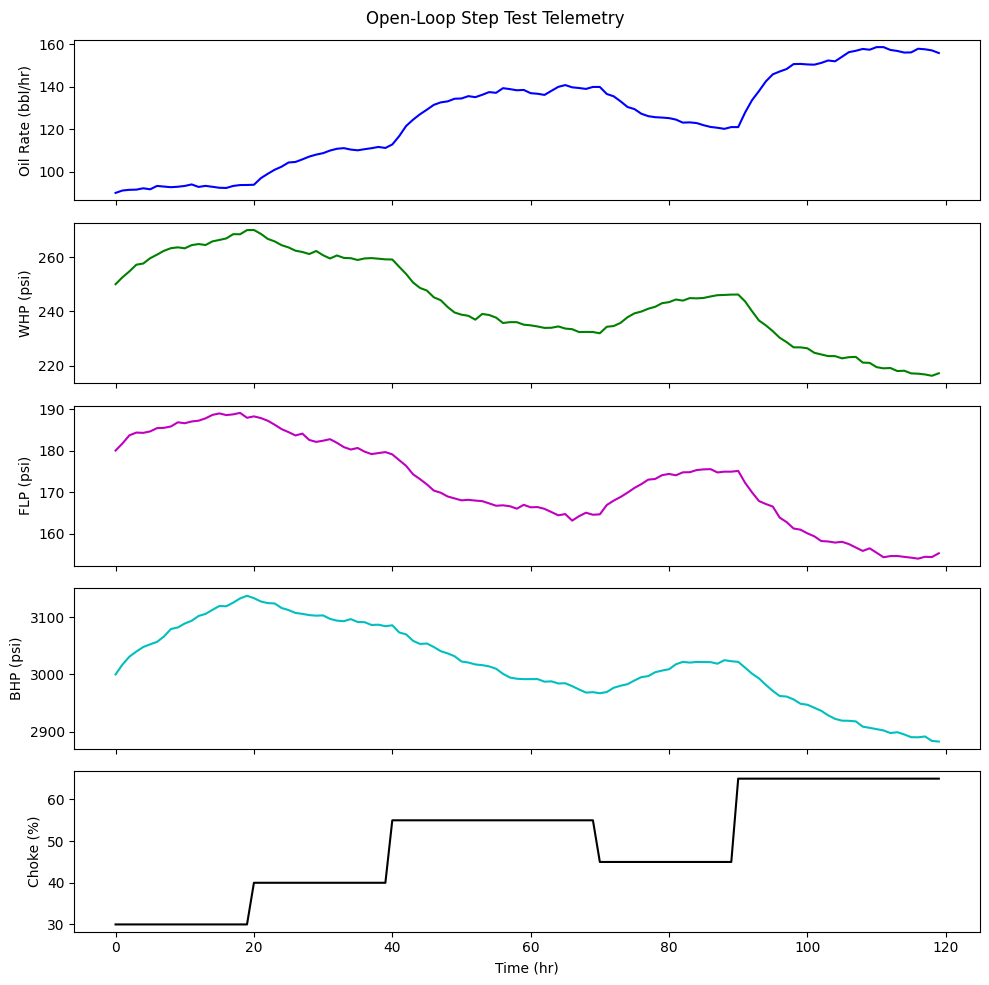

In [6]:
sys_model = DynamicSystemModel(dataset_path=dataset_path)
print('Safety Envelope Limits:', sys_model.safety_envelope)

if sys_model.df is not None:
    # Plot step-test dataset
    fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
    axes[0].plot(sys_model.df['Time_hr'], sys_model.df['OilRate_bbl_hr'], 'b-')
    axes[0].set_ylabel('Oil Rate (bbl/hr)')
    axes[1].plot(sys_model.df['Time_hr'], sys_model.df['WHP_psi'], 'g-')
    axes[1].set_ylabel('WHP (psi)')
    axes[2].plot(sys_model.df['Time_hr'], sys_model.df['FLP_psi'], 'm-')
    axes[2].set_ylabel('FLP (psi)')
    axes[3].plot(sys_model.df['Time_hr'], sys_model.df['BHP_psi'], 'c-')
    axes[3].set_ylabel('BHP (psi)')
    axes[4].plot(sys_model.df['Time_hr'], sys_model.df['Choke_pct'], 'k-')
    axes[4].set_ylabel('Choke (%)')
    axes[4].set_xlabel('Time (hr)')
    plt.suptitle('Open-Loop Step Test Telemetry')
    plt.tight_layout()
    plt.show()

## 3. FlowGuard-MPC Autonomous Controller Initialization

In [3]:
from mpc_controller import AutonomousChokeController
from simulator import OilWellSimulator

sim = OilWellSimulator()
controller = AutonomousChokeController(whp_min=210.0, flp_min=150.0, bhp_min=2850.0, max_ramp=5.0)
print('FlowGuard-MPC initialized with Hard-Guard Safety Filter.')

FlowGuard-MPC initialized with Hard-Guard Safety Filter.


## 4. Scenario Evaluation & Demonstration Plots
Executing Scenario A (Startup), Scenario B (Target Tracking), and Scenario C (Infeasible Target).

In [7]:
import importlib
import run_scenarios
importlib.reload(run_scenarios)
from run_scenarios import run_simulation, plot_scenario_results

# Scenario A
df_A, rejections_A = run_simulation('Scenario A', [110.0]*50, timesteps=50, initial_choke=30.0)
print('Scenario A Final Q:', round(df_A['Actual_Q'].iloc[-1], 2), 'bbl/hr')

# Scenario B
df_B, rejections_B = run_simulation('Scenario B', [100.0]*25 + [150.0]*25, timesteps=50, initial_choke=35.0)
print('Scenario B Final Q:', round(df_B['Actual_Q'].iloc[-1], 2), 'bbl/hr')

# Scenario C
df_C, rejections_C = run_simulation('Scenario C', [220.0]*50, timesteps=50, initial_choke=30.0)
print('Scenario C Settled Q:', round(df_C['Actual_Q'].iloc[-1], 2), 'bbl/hr (Safe limit maintained)')
print('Scenario C Candidate Moves Rejected:', len(rejections_C))

Generated plot: c:\Honeywell Project\Code\scenario_a_results.png
Scenario A Final Q: 120.38 bbl/hr
Generated plot: c:\Honeywell Project\Code\scenario_b_results.png
Scenario B Final Q: 163.02 bbl/hr
Generated plot: c:\Honeywell Project\Code\scenario_c_results.png
Scenario C Settled Q: 161.54 bbl/hr (Safe limit maintained)
Scenario C Candidate Moves Rejected: 2124
